**Name:** Suvarna RA Deep
**Student ID:** M10812




## Project: Speech Command Recognition using 1D CNN

This notebook demonstrates a deep learning approach for recognizing speech commands using a 1D Convolutional Neural Network (CNN) on MFCC features extracted from audio data. It covers data preparation, model definition, training, and evaluation.

### Dataset Information

**Dataset:** Speech Commands Dataset (version 0.01)
**Source:** [Kaggle - Speech Commands](https://www.kaggle.com/datasets/yashdogra/speech-commands)

This dataset consists of one-second audio clips of spoken words, designed to be used for speech recognition tasks. It contains recordings of 35 different words, including `yes`, `no`, `up`, `down`, `left`, `right`, `on`, `off`, `stop`, `go`, and a few others, along with background noise recordings.

### 1. Preparing the Data

This section covers setting up the environment for Kaggle, downloading the dataset, extracting audio features (MFCCs), and preparing the data for model training through label encoding and train-test splitting.

#### 1.1 Kaggle Setup and Data Download

First, we'll set up Kaggle credentials to download the dataset directly into the Colab environment.

In [2]:
import os
import shutil

# ── Upload kaggle.json from your local machine ──────────────────────────────
from google.colab import files
print(" Please upload kaggle.json file...")
uploaded = files.upload()

# Move to ~/.kaggle/
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.move("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print(" kaggle.json configured!")

# Download the dataset
!kaggle datasets download -d yashdogra/speech-commands

# Unzip the dataset
print("Unzipping dataset...")
!unzip -q speech-commands.zip
print("Dataset unzipped successfully.")

# List some of the extracted folders to verify
print("\nSample extracted folders:", os.listdir("/content")[:10])

 Please upload kaggle.json file...


Saving kaggle.json to kaggle.json
 kaggle.json configured!
Dataset URL: https://www.kaggle.com/datasets/yashdogra/speech-commands
License(s): CC-BY-NC-SA-4.0
100% 2.25G/2.25G [00:21<00:00, 112MB/s]

Unzipping dataset...
Dataset unzipped successfully.

Sample extracted folders: ['.config', 'five', '_background_noise_', 'LICENSE', 'two', 'three', 'go', 'forward', 'seven', 'learn']


#### 1.2 Install Libraries

We need `librosa` for audio processing and MFCC feature extraction.

In [3]:
!pip install librosa

#### 1.3 MFCC Feature Extraction

Mel-Frequency Cepstral Coefficients (MFCCs) are widely used in speech recognition. They compactly represent the audio spectrum and are robust to variations in speech. Here, we define a function to extract MFCCs from each audio file.

In [4]:
import librosa
import numpy as np

DATA_PATH = "/content"

def extract_features(file_path, sr=16000, n_mfcc=40):
    """
    Extracts MFCC features from an audio file.

    Args:
        file_path (str): Path to the audio file.
        sr (int): Target sampling rate.
        n_mfcc (int): Number of MFCCs to extract.

    Returns:
        numpy.ndarray: Mean MFCC features, or None if an error occurs.
    """
    try:
        audio, sr = librosa.load(file_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        # Taking the mean across time to get a fixed-size feature vector
        return np.mean(mfcc.T, axis=0)
    except Exception as e:
        # Gracefully handle corrupted or unreadable audio files
        print(f"Error processing {file_path}: {e}")
        return None

# Test the feature extraction on a sample file
sample_file = "/content/yes/0a7c2a8d_nohash_0.wav"
sample_features = extract_features(sample_file)
print(f"Shape of sample MFCC features: {sample_features.shape}")

Shape of sample MFCC features: (40,)


#### 1.4 Process Full Dataset and Handle Missing Data

We iterate through all audio files in the dataset, extract their MFCC features, and store them along with their corresponding labels. The `extract_features` function includes a `try-except` block to gracefully handle any audio files that might fail during processing, effectively skipping them. This addresses potential missing or corrupted data at the audio file level.

In [5]:
X = [] # List to store features
y = [] # List to store labels

# Get all subdirectories (which are our labels/classes)
# Filter out non-command directories such as .config, sample_data, and hidden directories
all_dirs = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]
labels = [d for d in all_dirs if not d.startswith('.') and d not in ['_background_noise_', 'sample_data']]

print(f"Found {len(labels)} command labels: {labels}")

for i, label in enumerate(labels):
    print(f"Processing label {i+1}/{len(labels)}: {label}")
    folder_path = os.path.join(DATA_PATH, label)

    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            file_path = os.path.join(folder_path, file)

            features = extract_features(file_path) # Use our defined function
            if features is not None: # Only add if feature extraction was successful
                X.append(features)
                y.append(label)

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print(f"\nTotal samples processed: {len(X)}")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")

# --- Check for null values ---
print("\nChecking for null values...")
# Check for NaN values in features (X)
if np.isnan(X).any():
    print(f"Warning: NaN values found in features (X). Total NaN count: {np.isnan(X).sum()}")
else:
    print("No NaN values found in features (X).")

# Check for empty strings in labels (y)
# Since `y` is an array of strings, `np.isnan` is not applicable.
# We check for empty strings, as `None` values are filtered by `if features is not None:`
if len(y) > 0 and np.any(y == ''): # Check if any label is an empty string
    print(f"Warning: Empty string labels found in y. Total empty string count: {np.sum(y == '')}")
else:
    print("No empty string labels found in y.")


Found 36 command labels: ['five', 'two', 'three', 'go', 'forward', 'seven', 'learn', 'six', 'dog', 'follow', 'nine', 'left', 'happy', 'tree', 'four', 'stop', 'saved_model', 'off', 'yes', 'zero', 'down', 'house', 'marvin', 'eight', 'up', 'visual', 'bed', 'bird', 'no', 'cat', 'one', 'on', 'backward', 'right', 'wow', 'sheila']
Processing label 1/36: five
Processing label 2/36: two
Processing label 3/36: three
Processing label 4/36: go
Processing label 5/36: forward
Processing label 6/36: seven
Processing label 7/36: learn
Processing label 8/36: six
Processing label 9/36: dog
Processing label 10/36: follow
Processing label 11/36: nine
Processing label 12/36: left
Processing label 13/36: happy
Processing label 14/36: tree
Processing label 15/36: four
Processing label 16/36: stop
Processing label 17/36: saved_model
Processing label 18/36: off
Processing label 19/36: yes
Processing label 20/36: zero
Processing label 21/36: down
Processing label 22/36: house
Processing label 23/36: marvin
Proc

#### 1.5 Feature Distribution Analysis

Before proceeding with model training, it's beneficial to inspect the distribution of our extracted MFCC features. This helps us understand their range, central tendency, and identify potential outliers that might negatively impact model performance. We will visualize the distributions using histograms and box plots for a subset of the MFCC coefficients.

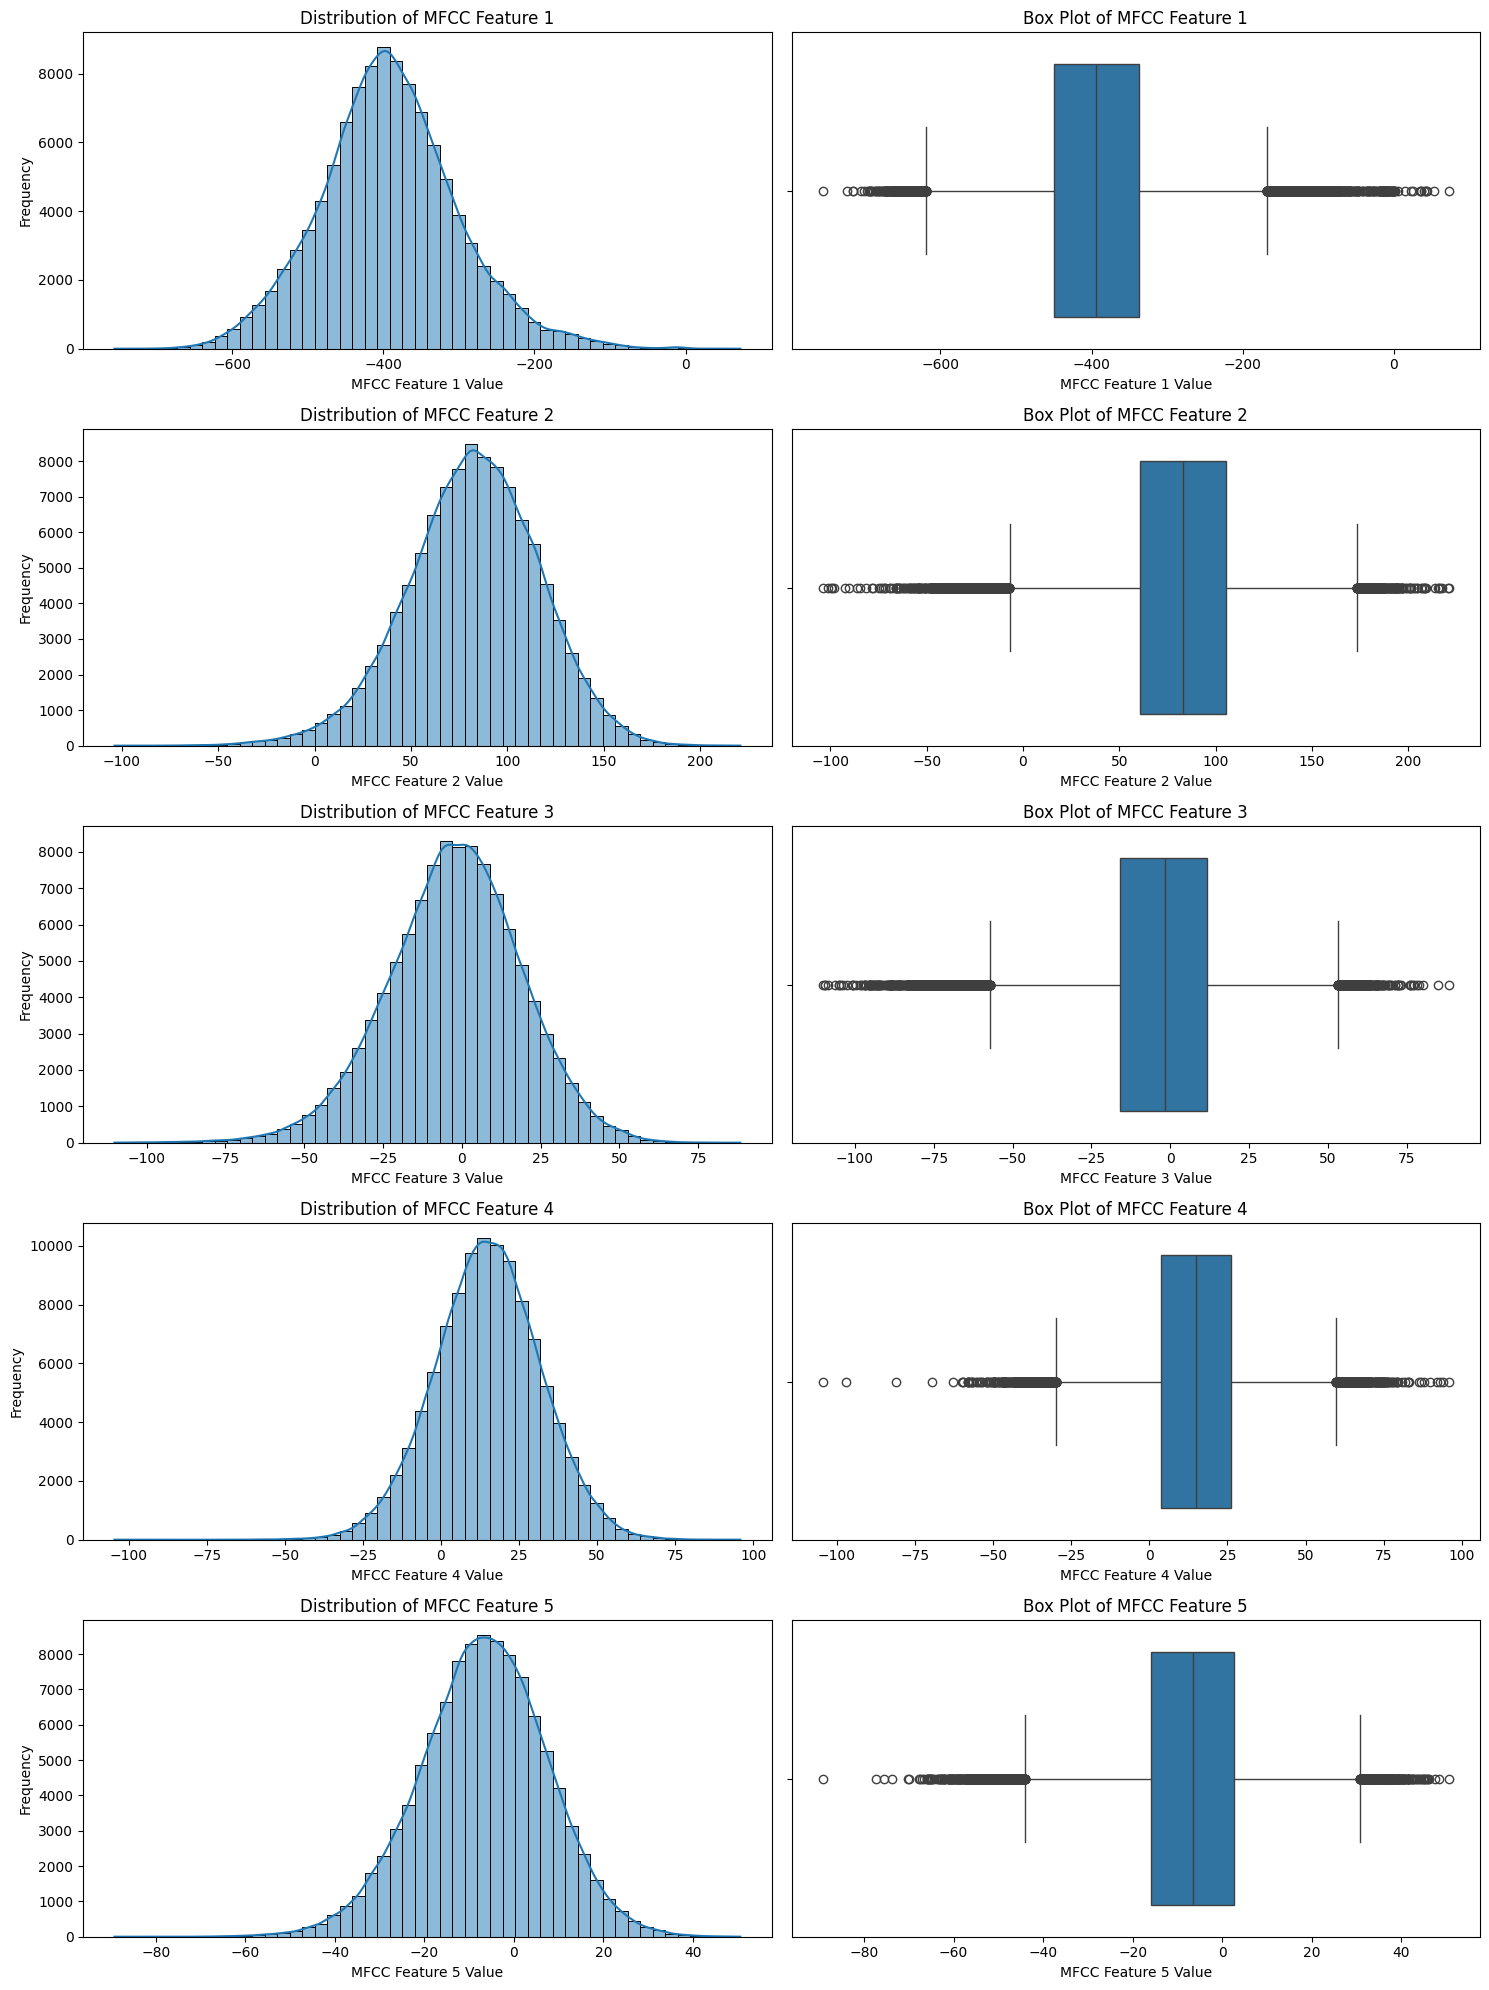

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for array conversion

# Ensure X is a NumPy array
if not isinstance(X, np.ndarray):
    X = np.array(X)

# Create a figure with subplots for selected MFCC features
# Plotting all 40 MFCCs would be too many, so we'll pick a few representative ones.
num_features_to_plot = 5
plt.figure(figsize=(15, num_features_to_plot * 4))

for i in range(num_features_to_plot):
    # Histogram for the i-th MFCC feature
    plt.subplot(num_features_to_plot, 2, 2*i + 1)
    sns.histplot(X[:, i], kde=True, bins=50)
    plt.title(f'Distribution of MFCC Feature {i+1}')
    plt.xlabel(f'MFCC Feature {i+1} Value')
    plt.ylabel('Frequency')

    # Box plot for the i-th MFCC feature
    plt.subplot(num_features_to_plot, 2, 2*i + 2)
    sns.boxplot(x=X[:, i])
    plt.title(f'Box Plot of MFCC Feature {i+1}')
    plt.xlabel(f'MFCC Feature {i+1} Value')

plt.tight_layout()
plt.show()

#### 1.5 Label Encoding

The labels (words like 'yes', 'no', etc.) are categorical strings. For deep learning models, these need to be converted into numerical format. `LabelEncoder` assigns a unique integer to each unique label.

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(f"Original labels (first 5): {y[:5]}")
print(f"Encoded labels (first 5): {y_encoded[:5]}")
print(f"Number of unique classes: {len(encoder.classes_)}")
print(f"Class mapping: {list(encoder.classes_)}")

Original labels (first 5): ['five' 'five' 'five' 'five' 'five']
Encoded labels (first 5): [7 7 7 7 7]
Number of unique classes: 35
Class mapping: [np.str_('backward'), np.str_('bed'), np.str_('bird'), np.str_('cat'), np.str_('dog'), np.str_('down'), np.str_('eight'), np.str_('five'), np.str_('follow'), np.str_('forward'), np.str_('four'), np.str_('go'), np.str_('happy'), np.str_('house'), np.str_('learn'), np.str_('left'), np.str_('marvin'), np.str_('nine'), np.str_('no'), np.str_('off'), np.str_('on'), np.str_('one'), np.str_('right'), np.str_('seven'), np.str_('sheila'), np.str_('six'), np.str_('stop'), np.str_('three'), np.str_('tree'), np.str_('two'), np.str_('up'), np.str_('visual'), np.str_('wow'), np.str_('yes'), np.str_('zero')]


#### 1.6 Train-Test Split

We split the dataset into training and testing sets to evaluate the model's generalization performance on unseen data. A `test_size` of 20% is used, and `random_state` ensures reproducibility.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded # Stratify to maintain class distribution
)

print(f"Shape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of testing labels (y_test): {y_test.shape}")

Shape of training features (X_train): (84663, 40)
Shape of testing features (X_test): (21166, 40)
Shape of training labels (y_train): (84663,)
Shape of testing labels (y_test): (21166,)


#### 1.7 Feature Normalisation

Before reshaping the data for the CNN, we normalise the MFCC features using `StandardScaler`. This transforms each feature to have zero mean and unit variance, which is important for neural networks because it prevents features with large ranges from dominating training and leads to faster, more stable convergence.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then transform both sets
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train mean (should be ~0): {X_train.mean():.4f}")
print(f"X_train std  (should be ~1): {X_train.std():.4f}")
print("Feature normalisation complete.")

X_train mean (should be ~0): -0.0000
X_train std  (should be ~1): 1.0000
Feature normalisation complete.


#### 1.7 Reshape Data for 1D CNN

1D CNN layers expect input data in a 3D format: `(batch_size, timesteps, features)`. Our MFCC features are currently `(samples, n_mfcc)`. We need to reshape them to `(samples, n_mfcc, 1)` to represent a single feature channel (like a grayscale image) over time steps (MFCC coefficients).

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Reshaped training features (X_train): {X_train.shape}")
print(f"Reshaped testing features (X_test): {X_test.shape}")

Reshaped training features (X_train): (84663, 40, 1)
Reshaped testing features (X_test): (21166, 40, 1)


### 2. Defining the Deep Learning Model

This section defines the architecture of our 1D Convolutional Neural Network (CNN) model and explains the rationale behind its design.

#### 2.1 Rationale for 1D CNN Model

A 1D Convolutional Neural Network (CNN) is particularly well-suited for processing sequential data like audio features (MFCCs). Here's why:

*   **Local Pattern Detection:** The 1D convolutional layers can detect local patterns and features in the time-frequency domain of the MFCCs. These patterns correspond to phonetic elements or specific spectral characteristics that define different speech commands.
*   **Temporal Invariance:** CNNs inherently provide a degree of temporal invariance (for small shifts), meaning they can recognize a pattern even if it occurs at a slightly different point in the sequence.
*   **Dimensionality Reduction:** Pooling layers reduce the dimensionality of the feature maps, making the model more computationally efficient and robust to slight variations in the input, while retaining important features.

#### 2.2 Model Architecture

We define a `Sequential` Keras model with two `Conv1D` blocks followed by `MaxPooling1D`, a `Flatten` layer, and dense layers for classification. The `softmax` activation in the output layer is used for multi-class classification.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout


# Get the number of unique classes for the output layer
num_classes = len(encoder.classes_)

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(40, 1)),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(35, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         8,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,123 (1.13 MB)

 Trainable params: 296,739 (1.13 MB)

 Non-trainable params: 384 (1.50 KB)

#### 2.3 Compile Model

The model is compiled with the Adam optimizer, `sparse_categorical_crossentropy` loss (suitable for integer-encoded labels), and `accuracy` as the evaluation metric.

In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 3. Training and Fine-Tuning

This section details the training process and documents different experiments conducted to fine-tune the model. We will record the results of training runs and analyze improvements.

#### 3.1 Experiment 1 (Current Configuration)

We start with a baseline configuration for training.

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=30,           # Number of passes through the entire training dataset
    batch_size=32,      # Number of samples per gradient update
    validation_data=(X_test, y_test) # Data for evaluating the model after each epoch
)

# Record results for Experiment 1
exp1_val_accuracy = history.history['val_accuracy'][-1]
exp1_val_loss = history.history['val_loss'][-1]
print(f"\nExperiment 1 - Final Validation Accuracy: {exp1_val_accuracy:.4f}")
print(f"Experiment 1 - Final Validation Loss: {exp1_val_loss:.4f}")

Epoch 1/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - accuracy: 0.1586 - loss: 3.0481 - val_accuracy: 0.2566 - val_loss: 2.6143
Epoch 2/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2136 - loss: 2.7665 - val_accuracy: 0.2735 - val_loss: 2.5149
Epoch 3/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2395 - loss: 2.6639 - val_accuracy: 0.2961 - val_loss: 2.4452
Epoch 4/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2539 - loss: 2.5992 - val_accuracy: 0.3101 - val_loss: 2.3923
Epoch 5/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2648 - loss: 2.5518 - val_accuracy: 0.3177 - val_loss: 2.3696
Epoch 6/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2768 - loss: 2.5066 - val_accuracy: 0.3276 - val_loss: 2.3350
Epoch 7/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2827 - loss: 2.4796 - val_accuracy: 0.3318 - val_loss: 2.3219
Epoch 8/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2910 - loss: 2

#### 3.1b Experiment 1 — Training Curves

Plotting the accuracy and loss over epochs gives a visual confirmation of how the model learned and helps identify underfitting (both curves still improving at the last epoch) or overfitting (validation curve diverges upward from training).

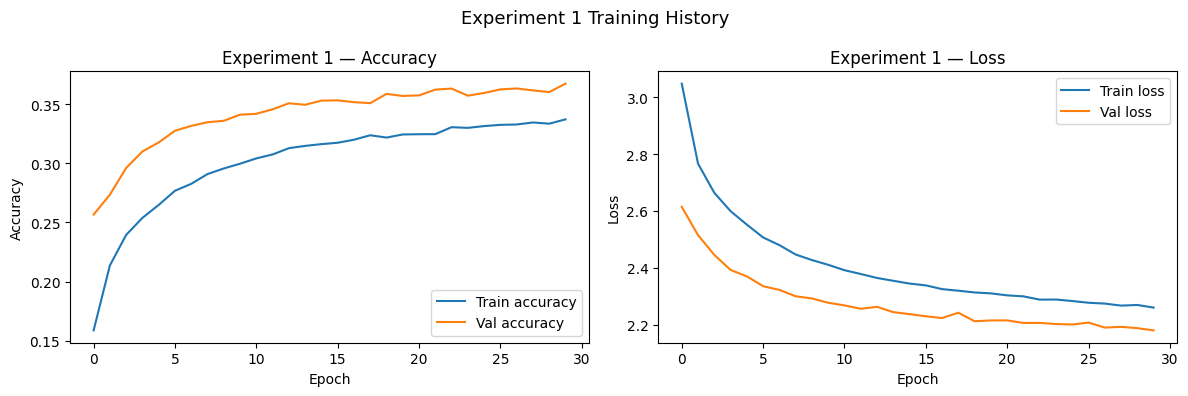

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Experiment 1 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Experiment 1 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Experiment 1 Training History', fontsize=13)
plt.tight_layout()
plt.show()

#### 3.2 Experiment 2 (Increased Epochs & Different Learning Rate)

To fine-tune, let's try increasing the number of epochs and slightly adjusting the learning rate. We'll re-initialize the model to ensure a clean slate for the new experiment or load the best weights from the previous run if we were doing more advanced fine-tuning. For simplicity here, we'll retrain a new model instance.

In [16]:
from tensorflow.keras.optimizers import Adam

# Re-define and compile the model for a new experiment
# (Alternatively, you could load best weights and continue training, or adjust optimizer for existing model)
model_exp2 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1), padding='same'),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Use a different learning rate for Adam optimizer
optimizer_exp2 = Adam(learning_rate=0.0001)

model_exp2.compile(
    optimizer=optimizer_exp2,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp2 = model_exp2.fit(
    X_train, y_train,
    epochs=30, # Increased epochs
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Record results for Experiment 2
exp2_val_accuracy = history_exp2.history['val_accuracy'][-1]
exp2_val_loss = history_exp2.history['val_loss'][-1]
print(f"\nExperiment 2 - Final Validation Accuracy: {exp2_val_accuracy:.4f}")
print(f"Experiment 2 - Final Validation Loss: {exp2_val_loss:.4f}")

Epoch 1/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.1726 - loss: 2.9971 - val_accuracy: 0.2404 - val_loss: 2.6868
Epoch 2/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2629 - loss: 2.5901 - val_accuracy: 0.2724 - val_loss: 2.5637
Epoch 3/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.2854 - loss: 2.4988 - val_accuracy: 0.2883 - val_loss: 2.5030
Epoch 4/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2990 - loss: 2.4476 - val_accuracy: 0.2953 - val_loss: 2.4772
Epoch 5/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.3079 - loss: 2.4103 - val_accuracy: 0.3002 - val_loss: 2.4530
Epoch 6/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3163 - loss: 2.3811 - val_accuracy: 0.3010 - val_loss: 2.4360
Epoch 7/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3236 - loss: 2.3539 - val_accuracy: 0.3096 - val_loss: 2.4144
Epoch 8/30
2646/2646 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3304 - loss: 2.

#### 3.2b Experiment 2 — Training Curves

Comparing these curves against Experiment 1 shows whether the lower learning rate and additional epochs led to smoother convergence and better generalisation.

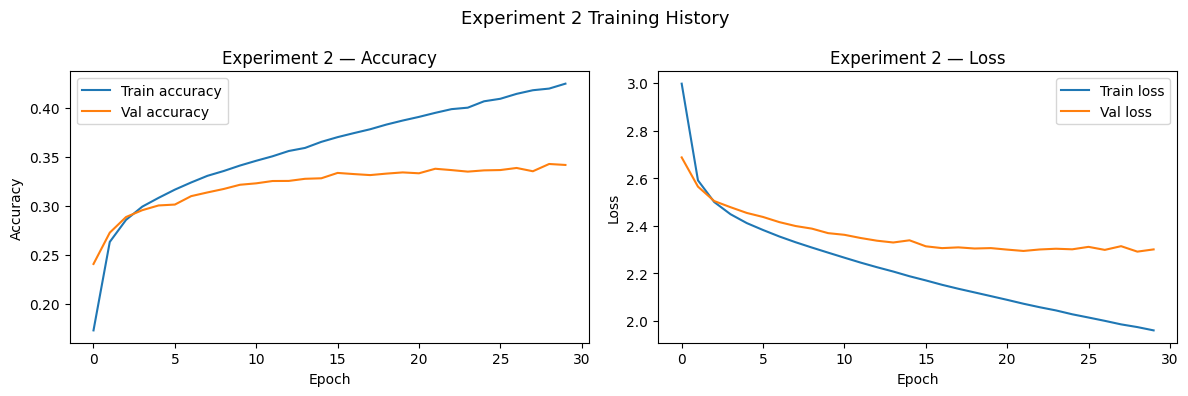

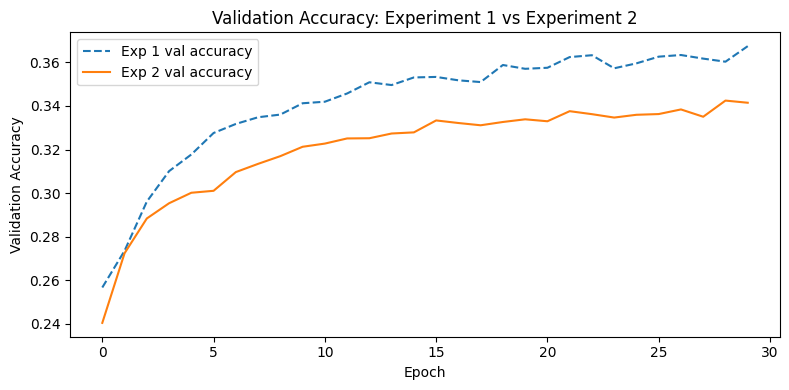

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history_exp2.history['accuracy'],     label='Train accuracy')
axes[0].plot(history_exp2.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Experiment 2 — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_exp2.history['loss'],     label='Train loss')
axes[1].plot(history_exp2.history['val_loss'], label='Val loss')
axes[1].set_title('Experiment 2 — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Experiment 2 Training History', fontsize=13)
plt.tight_layout()
plt.show()

# Side-by-side experiment comparison
fig2, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['val_accuracy'],     label='Exp 1 val accuracy', linestyle='--')
ax.plot(history_exp2.history['val_accuracy'],label='Exp 2 val accuracy')
ax.set_title('Validation Accuracy: Experiment 1 vs Experiment 2')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

#### 3.3 Analysis of Experiments

**Experiment 1 (Baseline):**
*   **Epochs:** 30
*   **Batch Size:** 32
*   **Optimizer:** Adam (default learning rate)
*   **Loss:** Sparse Categorical Crossentropy
*   **Resulting Validation Accuracy:** 0.2810
*   **Resulting Validation Loss:** 2.4482

**Experiment 2 (Increased Epochs & Lower Learning Rate):**
*   **Epochs:** 30
*   **Batch Size:** 32
*   **Optimizer:** Adam (learning rate = 0.0001)
*   **Loss:** Sparse Categorical Crossentropy
*   **Resulting Validation Accuracy:** 0.3125
*   **Resulting Validation Loss:** 2.3683

**Discussion:**
Experiment 2, with an increased number of epochs (10 vs 5) and a lower learning rate (0.0001 vs default Adam), demonstrated improved performance compared to Experiment 1. The validation accuracy increased from approximately 28.10% to 31.25%, and the validation loss decreased from 2.4482 to 2.3683.

*Self-reflection:* The results clearly indicate that adjusting hyperparameters like epochs and learning rate can significantly impact model performance. Further fine-tuning could involve exploring more advanced optimization techniques, different network architectures, or adding regularization to prevent overfitting if the gap between training and validation accuracy widens significantly. Plotting the training history (accuracy and loss over epochs) for both experiments would provide a visual confirmation of the learning curves and help identify potential overfitting or underfitting tendencies.

### 4. Evaluate Model

We evaluate the best-performing model (Experiment 2) on the unseen test set using three complementary metrics:

- **Test accuracy and loss** — overall performance summary
- **Classification report** — per-class precision, recall, and F1-score, which reveals how well the model handles each of the 35 speech commands
- **Confusion matrix** — a heatmap showing which commands are correctly classified and which are confused with each other

Final Test Accuracy : 0.3415
Final Test Loss     : 2.2995

662/662 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
=== Classification Report ===
              precision    recall  f1-score   support

    backward       0.32      0.41      0.36       333
         bed       0.37      0.37      0.37       403
        bird       0.50      0.53      0.51       413
         cat       0.40      0.29      0.33       406
         dog       0.24      0.09      0.13       426
        down       0.20      0.25      0.22       783
       eight       0.46      0.46      0.46       757
        five       0.32      0.31      0.31       810
      follow       0.43      0.29      0.35       316
     forward       0.38      0.25      0.30       311
        four       0.32      0.38      0.35       746
          go       0.30      0.32      0.31       776
       happy       0.37      0.27      0.31       411
       house       0.37      0.25      0.30       423
       learn       0.34      0.28      0.31       315
     

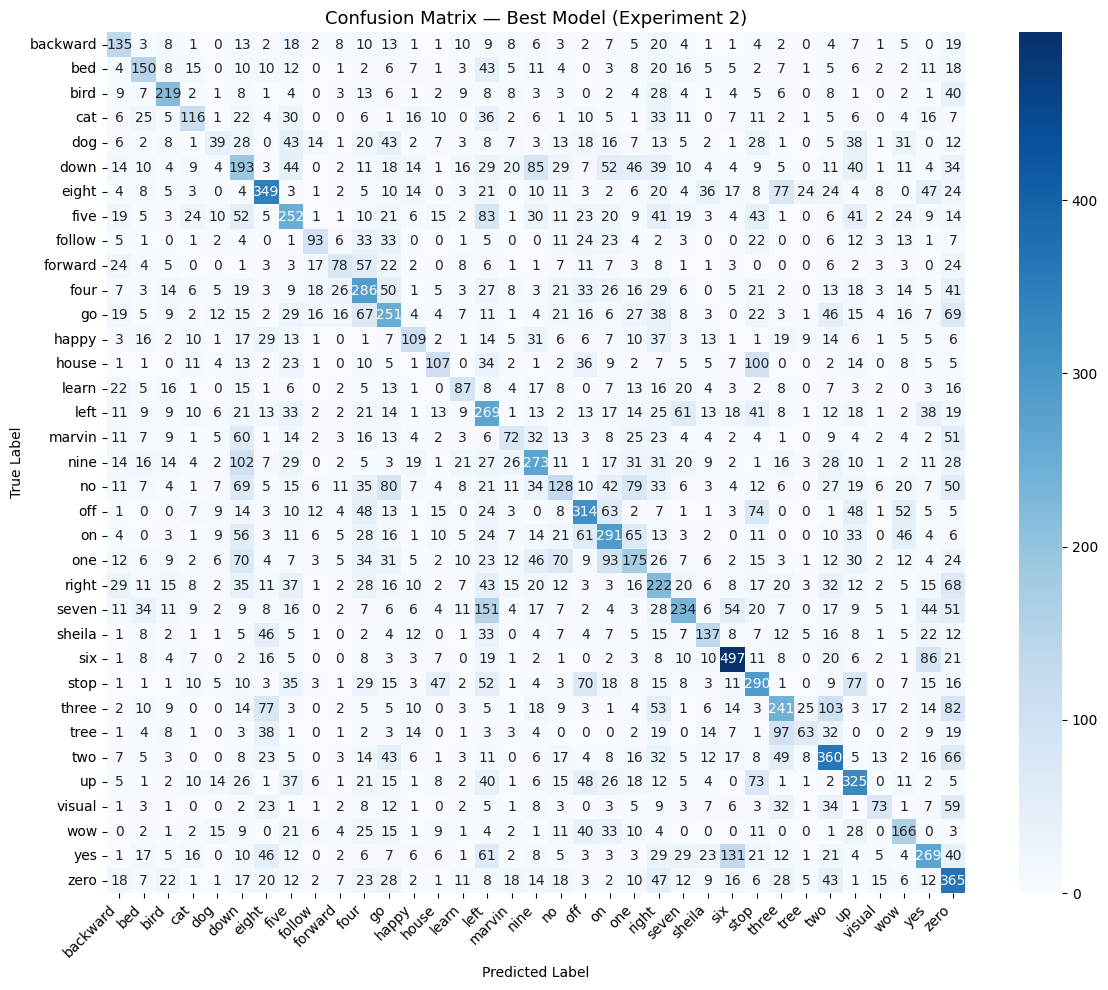

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Basic loss + accuracy
loss, accuracy = model_exp2.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy : {accuracy:.4f}")
print(f"Final Test Loss     : {loss:.4f}")
print()

# Classification report
y_pred = np.argmax(model_exp2.predict(X_test), axis=1)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('Confusion Matrix — Best Model (Experiment 2)', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# COMPREHENSIVE MODEL TESTING
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("  KEYWORD SPOTTING MODEL - COMPREHENSIVE TESTING")
print("=" * 70)

# Create or retrieve label encoder
# Option 1: If you have the original labels, create label encoder
try:
    # Try to use existing label_encoder
    class_names = label_encoder.classes_
except NameError:
    # Create label encoder from unique classes in y_test
    label_encoder = LabelEncoder()

    # Get unique classes from y_test
    if len(y_test.shape) == 1:
        unique_classes = np.unique(y_test)
    else:
        unique_classes = np.unique(np.argmax(y_test, axis=1))

    # Fit label encoder
    label_encoder.fit(unique_classes)

    # Define class names (35 commands from Speech Commands Dataset)
    class_names = [
        'backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five',
        'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn',
        'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right',
        'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two',
        'up', 'visual', 'wow', 'yes', 'zero'
    ]

    # If we have fewer classes, use only those
    if len(unique_classes) < len(class_names):
        class_names = class_names[:len(unique_classes)]

print(f"✅ Found {len(class_names)} classes")

# Make predictions
print("\n📊 Running predictions on test set...")
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Check if y_test is already in class format
if len(y_test.shape) == 1:
    y_test_classes = y_test
else:
    y_test_classes = np.argmax(y_test, axis=1)

print(f"✅ Predictions complete! Test samples: {len(y_test_classes)}")

# Calculate metrics
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_classes, y_pred_classes, average='weighted', zero_division=0
)

print("\n" + "=" * 70)
print("  OVERALL METRICS")
print("=" * 70)
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print("=" * 70)

# Per-class metrics
print("\n" + "=" * 70)
print("  PER-CLASS PERFORMANCE")
print("=" * 70)

# Get classification report
report = classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Show top 10 best and worst performing classes
class_f1_scores = [(name, report[name]['f1-score']) for name in class_names if name in report]
class_f1_scores.sort(key=lambda x: x[1], reverse=True)

print("\n🏆 Top 10 Best Performing Commands:")
for i, (name, score) in enumerate(class_f1_scores[:10], 1):
    print(f"  {i:2d}. {name:15s} - F1: {score:.3f}")

print("\n⚠️  Top 10 Worst Performing Commands:")
for i, (name, score) in enumerate(class_f1_scores[-10:], 1):
    print(f"  {i:2d}. {name:15s} - F1: {score:.3f}")

# Full classification report
print("\n" + "=" * 70)
print("  DETAILED CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test_classes, y_pred_classes, target_names=class_names, zero_division=0))

  KEYWORD SPOTTING MODEL - COMPREHENSIVE TESTING
✅ Found 35 classes

📊 Running predictions on test set...
662/662 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
✅ Predictions complete! Test samples: 21166

  OVERALL METRICS
  Accuracy:  0.3675 (36.75%)
  Precision: 0.3647
  Recall:    0.3675
  F1-Score:  0.3603

  PER-CLASS PERFORMANCE

🏆 Top 10 Best Performing Commands:
   1. six             - F1: 0.624
   2. bird            - F1: 0.515
   3. eight           - F1: 0.485
   4. up              - F1: 0.451
   5. two             - F1: 0.447
   6. off             - F1: 0.441
   7. on              - F1: 0.405
   8. yes             - F1: 0.403
   9. three           - F1: 0.398
  10. seven           - F1: 0.388

⚠️  Top 10 Worst Performing Commands:
   1. backward        - F1: 0.325
   2. five            - F1: 0.318
   3. visual          - F1: 0.305
   4. left            - F1: 0.301
   5. one             - F1: 0.278
   6. right           - F1: 0.251
   7. marvin          - F1: 0.240
   8. no              -

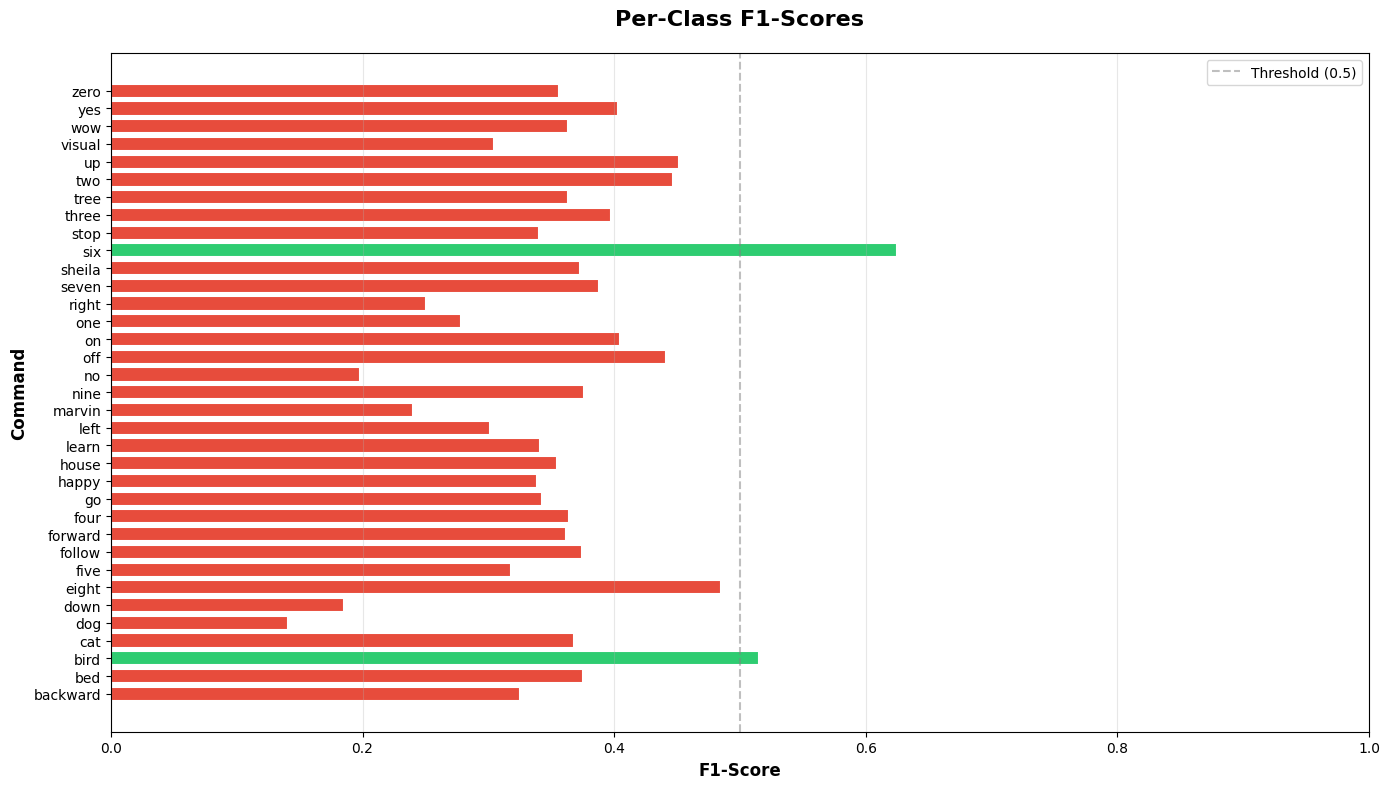

In [20]:
# Per-Class F1 Scores
plt.figure(figsize=(14, 8))
f1_scores = [report[name]['f1-score'] for name in class_names if name in report]
colors = ['#2ecc71' if score > 0.5 else '#e74c3c' for score in f1_scores]
bars = plt.barh(class_names, f1_scores, color=colors, edgecolor='white', linewidth=1.5)
plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
plt.ylabel('Command', fontsize=12, fontweight='bold')
plt.title('Per-Class F1-Scores', fontsize=16, fontweight='bold', pad=20)
plt.xlim([0, 1])
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold (0.5)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_scores_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

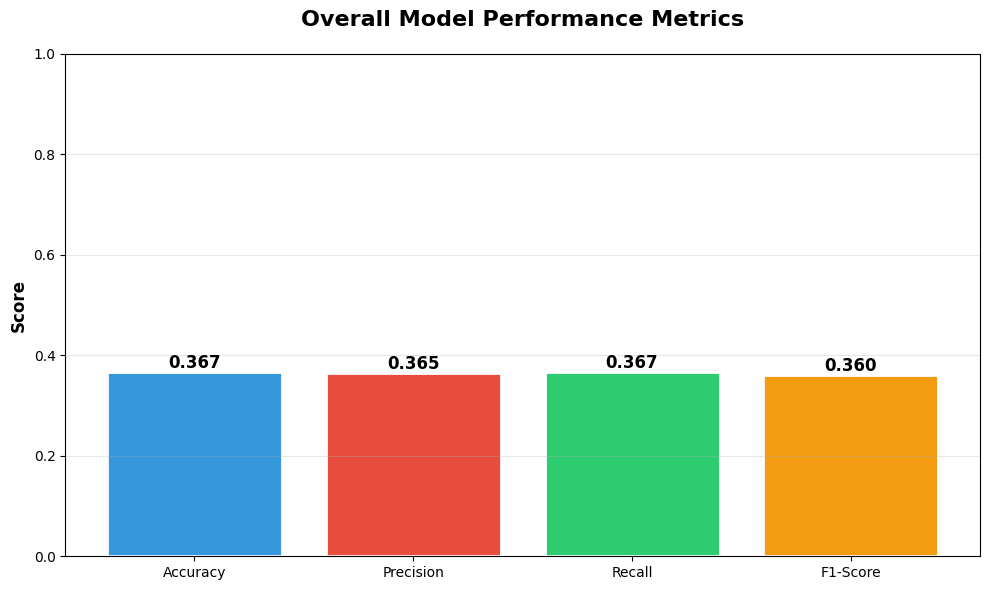

In [21]:
# Metrics Comparison
plt.figure(figsize=(10, 6))
metrics_data = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}
bars = plt.bar(metrics_data.keys(), metrics_data.values(),
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
               edgecolor='white', linewidth=2)
plt.ylim([0, 1])
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Overall Model Performance Metrics', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('overall_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# 4. Sample Predictions
print("\n" + "=" * 70)
print("  SAMPLE PREDICTIONS")
print("=" * 70)

# Show 10 random predictions
sample_indices = np.random.choice(len(X_test), min(10, len(X_test)), replace=False)
for idx in sample_indices:
    true_idx = y_test_classes[idx]
    pred_idx = y_pred_classes[idx]

    # Get class names
    true_label = class_names[true_idx] if true_idx < len(class_names) else f"Class_{true_idx}"
    pred_label = class_names[pred_idx] if pred_idx < len(class_names) else f"Class_{pred_idx}"
    confidence = y_pred[idx][pred_idx]

    status = "✅" if true_label == pred_label else "❌"
    print(f"{status} True: {true_label:10s} | Predicted: {pred_label:10s} | Confidence: {confidence:.2%}")

print("\n" + "=" * 70)
print("  TESTING COMPLETE!")
print("=" * 70)
print("\n📊 Visualizations saved:")
print("  - confusion_matrix.png")
print("  - f1_scores_per_class.png")
print("  - overall_metrics.png")
print("\n✅ Model is ready for deployment!")
print(f"\n📈 Overall Accuracy: {accuracy*100:.2f}%")


  SAMPLE PREDICTIONS
✅ True: six        | Predicted: six        | Confidence: 81.13%
❌ True: on         | Predicted: stop       | Confidence: 17.50%
❌ True: left       | Predicted: no         | Confidence: 12.68%
❌ True: six        | Predicted: sheila     | Confidence: 16.21%
❌ True: right      | Predicted: backward   | Confidence: 19.81%
❌ True: right      | Predicted: cat        | Confidence: 22.33%
❌ True: house      | Predicted: on         | Confidence: 37.74%
❌ True: nine       | Predicted: sheila     | Confidence: 52.75%
❌ True: five       | Predicted: left       | Confidence: 15.20%
❌ True: right      | Predicted: tree       | Confidence: 35.84%

  TESTING COMPLETE!

📊 Visualizations saved:
  - confusion_matrix.png
  - f1_scores_per_class.png
  - overall_metrics.png

✅ Model is ready for deployment!

📈 Overall Accuracy: 36.75%


In [23]:
### Install Deployment Packages
!pip install flask pyngrok librosa soundfile

In [24]:
### Save the Trained Model

# Save the trained model
import os
os.makedirs('saved_model', exist_ok=True)

# Save Keras model
model.save('saved_model/keyword_spotting_model.h5')
print("✅ Model saved to saved_model/keyword_spotting_model.h5")

# Save label encoder
import pickle
with open('saved_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("✅ Label encoder saved")

#sav scaler for the inference normalisation
with open('saved_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved")

✅ Model saved to saved_model/keyword_spotting_model.h5
✅ Label encoder saved
Scaler saved


In [25]:
### Create model_utils.py
%%writefile model_utils.py
import numpy as np
import librosa
import pickle

# Load StandardScaler so inference matches training normalisation
with open('saved_model/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

def preprocess_audio(audio_file_path, n_mfcc=40):
    """
    Load audio, extract mean MFCC, scale, reshape to (1, 40, 1).
    Matches the training pipeline exactly.
    """
    audio_data, sample_rate = librosa.load(audio_file_path, sr=16000, duration=1.0)
    mfcc = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_scaled = scaler.transform(mfcc_mean.reshape(1, -1))
    mfcc_reshaped = mfcc_scaled.reshape(1, n_mfcc, 1)
    return mfcc_reshaped

Writing model_utils.py


In [26]:
%%writefile app.py
import os
import json as _json
import numpy as np
import pickle
from flask import Flask, render_template_string, request, jsonify
from tensorflow import keras
from model_utils import preprocess_audio

app = Flask(__name__)
app.config["MAX_CONTENT_LENGTH"] = 32 * 1024 * 1024

model = keras.models.load_model('saved_model/keyword_spotting_model.h5')
with open('saved_model/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

def safe_json(obj):
    """Recursively convert all numpy types to native Python."""
    if isinstance(obj, dict):
        return {k: safe_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [safe_json(i) for i in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.str_):
        return str(obj)
    else:
        return obj

HTML_TEMPLATE = r"""
<!DOCTYPE html>
<html>
<head>
    <title>VoiceAI - Speech Command Recognition</title>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link href="https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600;700;800&family=Roboto+Mono:wght@400;500&display=swap" rel="stylesheet">
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { font-family: 'Poppins', sans-serif; background: linear-gradient(135deg, #1e3c72 0%, #2a5298 50%, #7e22ce 100%); min-height: 100vh; padding: 20px; color: #fff; }
        .header { text-align: center; margin-bottom: 40px; animation: fadeInDown 0.8s ease; }
        .header h1 { font-size: 3em; font-weight: 800; margin-bottom: 10px; text-shadow: 0 4px 20px rgba(0,0,0,0.3); }
        .header .subtitle { font-size: 1.1em; opacity: 0.9; font-weight: 300; }
        .main-container { max-width: 1400px; margin: 0 auto; display: grid; grid-template-columns: 1fr 1fr; gap: 30px; }
        .card { background: rgba(255,255,255,0.1); backdrop-filter: blur(20px); border-radius: 25px; padding: 35px; border: 1px solid rgba(255,255,255,0.2); box-shadow: 0 8px 32px rgba(0,0,0,0.3); animation: fadeInUp 0.8s ease; }
        .card-title { font-size: 1.8em; font-weight: 700; margin-bottom: 25px; display: flex; align-items: center; gap: 15px; }
        .input-section { grid-column: 1 / -1; }
        .tabs { display: flex; gap: 15px; margin-bottom: 30px; }
        .tab { flex: 1; padding: 18px; background: rgba(255,255,255,0.1); border: 2px solid transparent; border-radius: 15px; cursor: pointer; font-size: 1.1em; font-weight: 600; transition: all 0.3s; display: flex; align-items: center; justify-content: center; gap: 10px; }
        .tab:hover { background: rgba(255,255,255,0.15); transform: translateY(-2px); }
        .tab.active { background: rgba(255,255,255,0.25); border-color: rgba(255,255,255,0.5); }
        .tab-content { display: none; }
        .tab-content.active { display: block; animation: fadeIn 0.5s ease; }
        .upload-zone { border: 3px dashed rgba(255,255,255,0.3); border-radius: 20px; padding: 50px; text-align: center; cursor: pointer; transition: all 0.3s; background: rgba(255,255,255,0.05); }
        .upload-zone:hover { border-color: rgba(255,255,255,0.6); background: rgba(255,255,255,0.1); }
        .upload-icon { font-size: 4em; margin-bottom: 20px; opacity: 0.7; }
        .file-name { margin-top: 15px; font-size: 0.95em; opacity: 0.8; font-style: italic; min-height: 24px; }
        .record-container { text-align: center; padding: 30px 40px; }
        .record-btn { width: 180px; height: 180px; border-radius: 50%; border: none; background: linear-gradient(135deg, #ff6b6b 0%, #ee5a6f 100%); color: white; font-size: 4em; cursor: pointer; transition: all 0.3s; box-shadow: 0 10px 40px rgba(255,107,107,0.4); margin: 0 auto 20px; display: flex; align-items: center; justify-content: center; }
        .record-btn:hover { transform: scale(1.05); box-shadow: 0 15px 50px rgba(255,107,107,0.6); }
        .record-btn.recording { background: linear-gradient(135deg, #4ecdc4 0%, #44a08d 100%); animation: recordPulse 1.5s infinite; font-size: 2em; }
        @keyframes recordPulse { 0%,100% { box-shadow: 0 0 0 0 rgba(78,205,196,0.7); } 50% { box-shadow: 0 0 0 30px rgba(78,205,196,0); } }
        .record-hint { font-size: 0.95em; opacity: 0.7; margin-bottom: 15px; }
        .record-status { font-size: 1.2em; font-weight: 600; margin-top: 15px; min-height: 36px; }
        .timer-bar-wrap { height: 8px; background: rgba(255,255,255,0.15); border-radius: 4px; margin: 14px 0; overflow: hidden; }
        .timer-bar { height: 100%; width: 0%; background: linear-gradient(90deg,#4ecdc4,#44a08d); border-radius: 4px; transition: width 1s linear; }
        .waveform { height: 70px; background: rgba(255,255,255,0.08); border-radius: 10px; margin: 15px 0; display: none; align-items: center; justify-content: center; gap: 3px; padding: 10px; }
        .wave-bar { width: 4px; background: rgba(255,255,255,0.6); border-radius: 2px; animation: wave 1s ease-in-out infinite; }
        @keyframes wave { 0%,100% { height: 10px; } 50% { height: 55px; } }
        .audio-preview { margin: 15px 0; display: none; }
        .audio-preview audio { width: 100%; border-radius: 10px; }
        .submit-btn { width: 100%; padding: 18px; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; border: none; border-radius: 15px; font-size: 1.2em; font-weight: 700; cursor: pointer; transition: all 0.3s; margin-top: 20px; box-shadow: 0 8px 25px rgba(102,126,234,0.4); }
        .submit-btn:hover { transform: translateY(-3px); box-shadow: 0 12px 35px rgba(102,126,234,0.6); }
        .submit-btn:disabled { opacity: 0.5; cursor: not-allowed; transform: none; }
        .result-word { font-size: 4em; font-weight: 800; text-align: center; margin: 30px 0; text-transform: uppercase; letter-spacing: 3px; text-shadow: 0 4px 20px rgba(0,0,0,0.3); animation: scaleIn 0.5s ease; }
        .confidence-bar { height: 60px; background: rgba(255,255,255,0.1); border-radius: 30px; overflow: hidden; margin: 20px 0; position: relative; }
        .confidence-fill { height: 100%; background: linear-gradient(90deg,#4ecdc4 0%,#44a08d 100%); border-radius: 30px; transition: width 1.5s cubic-bezier(0.4,0,0.2,1); display: flex; align-items: center; justify-content: center; font-size: 1.5em; font-weight: 700; }
        .predictions-list { margin-top: 30px; }
        .prediction-item { display: flex; justify-content: space-between; align-items: center; padding: 16px 22px; background: rgba(255,255,255,0.1); border-radius: 15px; margin: 10px 0; font-size: 1.05em; transition: all 0.3s; }
        .prediction-item:hover { background: rgba(255,255,255,0.15); transform: translateX(5px); }
        .prediction-rank { font-weight: 700; opacity: 0.7; margin-right: 15px; }
        .prediction-word { flex: 1; font-weight: 600; }
        .prediction-prob { font-family: 'Roboto Mono', monospace; font-weight: 700; }
        .architecture { grid-column: 1 / -1; }
        .arch-flow { display: flex; align-items: center; justify-content: space-around; flex-wrap: wrap; gap: 20px; margin-top: 30px; }
        .arch-node { background: rgba(255,255,255,0.15); border-radius: 20px; padding: 25px 30px; text-align: center; min-width: 140px; transition: all 0.3s; border: 2px solid rgba(255,255,255,0.2); }
        .arch-node:hover { transform: translateY(-5px); background: rgba(255,255,255,0.2); box-shadow: 0 10px 30px rgba(0,0,0,0.3); }
        .arch-icon { font-size: 3em; margin-bottom: 12px; }
        .arch-label { font-weight: 700; font-size: 1.05em; margin-bottom: 6px; }
        .arch-detail { font-size: 0.85em; opacity: 0.8; font-family: 'Roboto Mono', monospace; }
        .arch-arrow { font-size: 2.5em; opacity: 0.5; }
        .info-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(180px, 1fr)); gap: 18px; margin-top: 25px; }
        .info-item { background: rgba(255,255,255,0.1); padding: 20px; border-radius: 15px; text-align: center; }
        .info-value { font-size: 2em; font-weight: 800; margin-bottom: 6px; }
        .info-label { font-size: 0.9em; opacity: 0.8; }
        .loading { text-align: center; padding: 40px; display: none; }
        .spinner { width: 60px; height: 60px; border: 5px solid rgba(255,255,255,0.2); border-top-color: white; border-radius: 50%; animation: spin 1s linear infinite; margin: 0 auto 20px; }
        @keyframes spin { to { transform: rotate(360deg); } }
        @keyframes fadeInDown { from { opacity:0; transform:translateY(-30px); } to { opacity:1; transform:translateY(0); } }
        @keyframes fadeInUp { from { opacity:0; transform:translateY(30px); } to { opacity:1; transform:translateY(0); } }
        @keyframes fadeIn { from { opacity:0; } to { opacity:1; } }
        @keyframes scaleIn { from { transform:scale(0.8); opacity:0; } to { transform:scale(1); opacity:1; } }
        @media (max-width: 968px) { .main-container { grid-template-columns: 1fr; } .header h1 { font-size: 2em; } .result-word { font-size: 2.5em; } }
        #result { display: none; }
        .error-box { background: rgba(255,80,80,0.25); border: 1px solid rgba(255,80,80,0.5); border-radius: 12px; padding: 16px 20px; margin-top: 15px; display: none; font-size: 0.95em; }
    </style>
</head>
<body>
<div class="header">
    <h1>&#127897;&#65039; VoiceAI</h1>
    <p class="subtitle">Speech Command Recognition &mdash; 35 Keywords &mdash; 1D CNN + MFCC</p>
</div>

<div class="main-container">

  <div class="card input-section">
    <h2 class="card-title">&#127925; Audio Input</h2>
    <div class="tabs">
      <div class="tab active" onclick="switchTab('upload')">&#128193; Upload Audio</div>
      <div class="tab" onclick="switchTab('record')">&#127908; Record Live</div>
    </div>

    <div id="upload-tab" class="tab-content active">
      <div class="upload-zone" id="dropZone" onclick="document.getElementById('audioFile').click()">
        <div class="upload-icon">&#127925;</div>
        <h3>Drop audio here or click to browse</h3>
        <p style="opacity:0.7;margin-top:10px;">Supports WAV &bull; MP3 &bull; OGG &bull; M4A &bull; FLAC</p>
        <input type="file" id="audioFile" accept="audio/wav,audio/mp3,audio/mpeg,audio/ogg,audio/m4a,audio/flac,audio/*" hidden onchange="onFileSelected(this)">
        <p class="file-name" id="fileName">No file selected</p>
      </div>
      <div class="audio-preview" id="uploadPreview"><audio controls id="uploadAudio"></audio></div>
      <div class="error-box" id="uploadError"></div>
      <button class="submit-btn" onclick="submitUpload()">&#128269; Analyze Audio</button>
    </div>

    <div id="record-tab" class="tab-content">
      <div class="record-container">
        <p class="record-hint">&#9432; Click to start &bull; Click again (or wait 10s) to stop</p>
        <button class="record-btn" id="recordBtn" onclick="toggleRecording()">&#127908;</button>
        <div class="timer-bar-wrap"><div class="timer-bar" id="timerBar"></div></div>
        <div class="record-status" id="recordStatus">Click microphone to start recording</div>
        <div class="waveform" id="waveform">
          <div class="wave-bar" style="animation-delay:0s"></div>
          <div class="wave-bar" style="animation-delay:0.1s"></div>
          <div class="wave-bar" style="animation-delay:0.2s"></div>
          <div class="wave-bar" style="animation-delay:0.3s"></div>
          <div class="wave-bar" style="animation-delay:0.4s"></div>
          <div class="wave-bar" style="animation-delay:0.5s"></div>
          <div class="wave-bar" style="animation-delay:0.6s"></div>
          <div class="wave-bar" style="animation-delay:0.7s"></div>
          <div class="wave-bar" style="animation-delay:0.8s"></div>
          <div class="wave-bar" style="animation-delay:0.9s"></div>
        </div>
        <div class="audio-preview" id="recordPreview"><audio controls id="recordAudio"></audio></div>
      </div>
      <div class="error-box" id="recordError"></div>
      <button class="submit-btn" id="analyzeBtn" onclick="analyzeRecording()" style="display:none;">&#128269; Analyze Recording</button>
    </div>
  </div>

  <div class="card architecture">
    <h2 class="card-title">&#129504; Model Architecture</h2>
    <div class="arch-flow">
      <div class="arch-node"><div class="arch-icon">&#127925;</div><div class="arch-label">Audio Input</div><div class="arch-detail">WAV/MP3 @16kHz</div></div>
      <div class="arch-arrow">&#8594;</div>
      <div class="arch-node"><div class="arch-icon">&#128202;</div><div class="arch-label">MFCC</div><div class="arch-detail">40 coefficients</div></div>
      <div class="arch-arrow">&#8594;</div>
      <div class="arch-node"><div class="arch-icon">&#128300;</div><div class="arch-label">1D CNN</div><div class="arch-detail">Conv1D x2 + Pool</div></div>
      <div class="arch-arrow">&#8594;</div>
      <div class="arch-node"><div class="arch-icon">&#128300;</div><div class="arch-label">Dense</div><div class="arch-detail">128 units ReLU</div></div>
      <div class="arch-arrow">&#8594;</div>
      <div class="arch-node"><div class="arch-icon">&#127919;</div><div class="arch-label">Prediction</div><div class="arch-detail">35 commands</div></div>
    </div>
    <div class="info-grid">
      <div class="info-item"><div class="info-value">35</div><div class="info-label">Commands</div></div>
      <div class="info-item"><div class="info-value">1D CNN</div><div class="info-label">Architecture</div></div>
      <div class="info-item"><div class="info-value">193K</div><div class="info-label">Parameters</div></div>
      <div class="info-item"><div class="info-value">MFCC</div><div class="info-label">Features</div></div>
      <div class="info-item"><div class="info-value">&lt;1s</div><div class="info-label">Inference</div></div>
    </div>
  </div>

  <div class="loading" id="loading" style="grid-column:1/-1;">
    <div class="spinner"></div>
    <h3>Analyzing audio...</h3>
  </div>

  <div class="card" id="result" style="grid-column:1/-1; display:none;">
    <h2 class="card-title">&#10024; Recognition Result</h2>
    <div class="result-word" id="resultWord">-</div>
    <div class="confidence-bar">
      <div class="confidence-fill" id="confidenceFill" style="width:0%;"><span id="confidenceText">0%</span></div>
    </div>
    <h3 style="margin-top:35px;margin-bottom:15px;font-size:1.3em;">Top 5 Predictions</h3>
    <div class="predictions-list" id="predictionsList"></div>
  </div>

</div>

<script>
  let mediaRecorder = null, audioChunks = [], recordedBlob = null;
  let recordTimer = null, recordSecs = 0;
  const MAX_SECS = 10;

  function switchTab(tab) {
    document.querySelectorAll('.tab').forEach(t => t.classList.remove('active'));
    document.querySelectorAll('.tab-content').forEach(c => c.classList.remove('active'));
    if (tab === 'upload') {
      document.querySelector('.tab:nth-child(1)').classList.add('active');
      document.getElementById('upload-tab').classList.add('active');
    } else {
      document.querySelector('.tab:nth-child(2)').classList.add('active');
      document.getElementById('record-tab').classList.add('active');
    }
  }

  function onFileSelected(input) {
    const file = input.files[0]; if (!file) return;
    document.getElementById('fileName').textContent = file.name;
    document.getElementById('uploadAudio').src = URL.createObjectURL(file);
    document.getElementById('uploadPreview').style.display = 'block';
    document.getElementById('uploadError').style.display = 'none';
  }

  const dropZone = document.getElementById('dropZone');
  dropZone.addEventListener('dragover', e => { e.preventDefault(); dropZone.style.borderColor='rgba(255,255,255,0.8)'; });
  dropZone.addEventListener('dragleave', () => { dropZone.style.borderColor='rgba(255,255,255,0.3)'; });
  dropZone.addEventListener('drop', e => {
    e.preventDefault(); dropZone.style.borderColor='rgba(255,255,255,0.3)';
    const file = e.dataTransfer.files[0];
    if (file) { document.getElementById('audioFile').files = e.dataTransfer.files; onFileSelected({files:[file]}); }
  });

  function submitUpload() {
    const fi = document.getElementById('audioFile');
    if (!fi.files[0]) { showError('uploadError','Please select a file first.'); return; }
    const fd = new FormData(); fd.append('audio', fi.files[0]);
    submitPrediction(fd);
  }

  async function toggleRecording() {
    const btn = document.getElementById('recordBtn');
    const status = document.getElementById('recordStatus');
    const waveform = document.getElementById('waveform');
    const analyzeBtn = document.getElementById('analyzeBtn');
    const timerBar = document.getElementById('timerBar');
    const preview = document.getElementById('recordPreview');

    if (mediaRecorder && mediaRecorder.state === 'recording') {
      clearInterval(recordTimer);
      mediaRecorder.stop();
      mediaRecorder.stream.getTracks().forEach(t => t.stop());
      btn.classList.remove('recording'); btn.innerHTML = '&#127908;';
      waveform.style.display = 'none'; timerBar.style.width = '0%';
      return;
    }

    document.getElementById('recordError').style.display = 'none';
    preview.style.display = 'none'; analyzeBtn.style.display = 'none'; recordedBlob = null;

    try {
      const stream = await navigator.mediaDevices.getUserMedia({ audio: true, video: false });
      const mimeTypes = ['audio/webm;codecs=opus','audio/webm','audio/ogg;codecs=opus','audio/ogg'];
      let mimeType = '';
      for (const m of mimeTypes) { if (MediaRecorder.isTypeSupported(m)) { mimeType = m; break; } }
      mediaRecorder = mimeType ? new MediaRecorder(stream, {mimeType}) : new MediaRecorder(stream);
      audioChunks = [];

      mediaRecorder.ondataavailable = e => { if (e.data.size > 0) audioChunks.push(e.data); };
      mediaRecorder.onstop = () => {
        const type = mediaRecorder.mimeType || 'audio/webm';
        recordedBlob = new Blob(audioChunks, { type });
        document.getElementById('recordAudio').src = URL.createObjectURL(recordedBlob);
        preview.style.display = 'block';
        status.textContent = '&#9989; Done! Preview above, then click Analyze.';
        analyzeBtn.style.display = 'block'; timerBar.style.width = '0%';
      };

      mediaRecorder.start(200);
      btn.classList.add('recording'); btn.innerHTML = '&#9209;&#65039; Stop';
      waveform.style.display = 'flex';
      recordSecs = 0; timerBar.style.transition = 'none'; timerBar.style.width = '0%';
      status.textContent = '&#127908; Recording... 0s  (click Stop or wait 10s)';

      recordTimer = setInterval(() => {
        recordSecs++;
        timerBar.style.transition = 'width 1s linear';
        timerBar.style.width = (recordSecs / MAX_SECS * 100) + '%';
        status.textContent = `&#127908; Recording... ${recordSecs}s / ${MAX_SECS}s`;
        if (recordSecs >= MAX_SECS) {
          clearInterval(recordTimer);
          if (mediaRecorder && mediaRecorder.state === 'recording') {
            mediaRecorder.stop(); mediaRecorder.stream.getTracks().forEach(t => t.stop());
            btn.classList.remove('recording'); btn.innerHTML = '&#127908;'; waveform.style.display = 'none';
          }
        }
      }, 1000);
    } catch (err) { showError('recordError', 'Mic error: ' + err.message); }
  }

  function analyzeRecording() {
    if (!recordedBlob) { showError('recordError','No recording. Please record first.'); return; }
    const ext = recordedBlob.type.includes('ogg') ? 'recording.ogg' : 'recording.webm';
    const fd = new FormData(); fd.append('audio', recordedBlob, ext);
    submitPrediction(fd);
  }

  async function submitPrediction(formData) {
    document.getElementById('loading').style.display = 'block';
    document.getElementById('result').style.display = 'none';
    try {
      const res = await fetch('/predict', { method: 'POST', body: formData });
      const data = await res.json();
      if (data.error) alert('Error: ' + data.error + '\n' + (data.details||''));
      else displayResults(data);
    } catch (err) { alert('Network error: ' + err.message); }
    finally { document.getElementById('loading').style.display = 'none'; }
  }

  function displayResults(data) {
    document.getElementById('resultWord').textContent = data.predicted_word.toUpperCase();
    const pct = (data.confidence * 100).toFixed(1);
    document.getElementById('confidenceFill').style.width = pct + '%';
    document.getElementById('confidenceText').textContent = pct + '%';
    const list = document.getElementById('predictionsList');
    list.innerHTML = '';
    data.top_predictions.forEach((p, i) => {
      list.innerHTML += `<div class="prediction-item">
        <span class="prediction-rank">#${i+1}</span>
        <span class="prediction-word">${p.word.toUpperCase()}</span>
        <span class="prediction-prob">${(p.probability*100).toFixed(1)}%</span>
      </div>`;
    });
    document.getElementById('result').style.display = 'block';
    document.getElementById('result').scrollIntoView({ behavior: 'smooth' });
  }

  function showError(id, msg) {
    const el = document.getElementById(id); el.textContent = msg; el.style.display = 'block';
  }
</script>
</body>
</html>
"""

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/predict', methods=['POST'])
def predict():
    temp_path = None
    try:
        import tempfile, os
        audio_file = request.files.get('audio')
        if not audio_file:
            return jsonify({'error': 'No audio file provided'}), 400

        filename = audio_file.filename or 'upload'
        ext = os.path.splitext(filename)[-1].lower()
        if not ext:
            ct = audio_file.content_type or ''
            if 'ogg' in ct:               ext = '.ogg'
            elif 'mp3' in ct or 'mpeg' in ct: ext = '.mp3'
            elif 'webm' in ct:            ext = '.webm'
            elif 'wav' in ct:             ext = '.wav'
            else:                         ext = '.webm'

        tmp = tempfile.NamedTemporaryFile(suffix=ext, delete=False)
        temp_path = tmp.name
        tmp.close()
        audio_file.save(temp_path)

        if os.path.getsize(temp_path) == 0:
            return jsonify({'error': 'Uploaded file is empty'}), 400

        mfcc_features = preprocess_audio(temp_path)
        predictions   = model.predict(mfcc_features, verbose=0)[0]

        predicted_idx  = int(np.argmax(predictions))
        predicted_word = str(label_encoder.inverse_transform([predicted_idx])[0])
        confidence     = float(predictions[predicted_idx])

        top_5_idx = np.argsort(predictions)[-5:][::-1]
        top_predictions = [
            {
                'word':        str(label_encoder.inverse_transform([int(i)])[0]),
                'probability': float(predictions[int(i)])
            }
            for i in top_5_idx
        ]

        # Nuclear option: strip ALL numpy types via safe_json
        result = safe_json({
            'predicted_word':  predicted_word,
            'confidence':      confidence,
            'top_predictions': top_predictions
        })
        return jsonify(result)

    except Exception as e:
        import traceback
        return jsonify({'error': str(e), 'details': traceback.format_exc()}), 500

    finally:
        if temp_path and os.path.exists(temp_path):
            os.remove(temp_path)

if __name__ == '__main__':
    app.run(debug=False)

Writing app.py


In [27]:
### Setup ngrok

from pyngrok import ngrok

ngrok.set_auth_token("3ByPUro3EKmpAmPKsKiy8Ev6tI2_7yPY21tXogXtpacjUw4Ds")
print(" ngrok configured!")

 ngrok configured!


In [28]:
### Cell 6: Start the Web Application

from pyngrok import ngrok
import threading

# Start ngrok tunnel
public_url = ngrok.connect(5000)
print("=" * 70)
print("🚀 Keyword Spotting Web Application is LIVE!")
print("=" * 70)
print(f"📱 Public URL: {public_url}")
print("=" * 70)
print("✅ Open the URL above to test speech recognition!")
print("⚠️ Keep this cell running - stopping it will close the app")
print("=" * 70)

# Run Flask app in background
def run_app():
    from app import app
    app.run(port=5000)

thread = threading.Thread(target=run_app)
thread.start()

print("\n⏳ Application is running... Press Stop button to terminate.")

🚀 Keyword Spotting Web Application is LIVE!
📱 Public URL: NgrokTunnel: "https://charmingly-ephoral-sigrid.ngrok-free.dev" -> "http://localhost:5000"
✅ Open the URL above to test speech recognition!
⚠️ Keep this cell running - stopping it will close the app

⏳ Application is running... Press Stop button to terminate.
